# ใบงานที่ 2: Data Preprocessing
### วิชา Machine Learning (04-624-201) — ภาควิชาวิศวกรรมคอมพิวเตอร์
**Dataset:** Thai Road Accident (2019–2022)

ใบงาน: LAB1 (Dataset Exploration), LAB2 (Data Visualization), Part 3 (Data Cleaning), Part 4 (Feature Engineering)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)

---

In [3]:
import matplotlib.font_manager as fm
import urllib.request

url = "https://github.com/google/fonts/raw/main/ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf"
font_path = "NotoSansThai.ttf"
urllib.request.urlretrieve(url, font_path)

fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

## LAB1: Dataset Exploration

### 1.1 Load Dataset

In [4]:
import pandas as pd

# โหลดข้อมูลดิบ (เปลี่ยนชื่อไฟล์ให้ตรงกับในเครื่องน้องนะครับ)
df = pd.read_csv('thai_road_accident_2019_2022.csv')

### 1.2 Display Shape

In [5]:
print(f"จำนวนแถว (rows): {df.shape[0]:,}")
print(f"จำนวนคอลัมน์ (columns): {df.shape[1]}")

จำนวนแถว (rows): 81,735
จำนวนคอลัมน์ (columns): 18


### 1.3 Display Data Types

In [6]:
df.dtypes.to_frame(name='dtype')

,dtype
acc_code,int64
incident_datetime,str
report_datetime,str
province_th,str
province_en,str
agency,str
route,str
vehicle_type,str
presumed_cause,str
accident_type,str


### 1.4 Display Summary Statistics

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acc_code,81735.0,NaN,NaN,NaN,4235766.317061,2128207.455614,571834.0,3789459.5,3824084.0,5831088.5,7571316.0
incident_datetime,81735,67917,2020-12-30 19:00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
report_datetime,81735,66234,2022-12-29 11:39:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province_th,81735,78,กรุงเทพมหานคร,6439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province_en,81735,78,Bangkok,6439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency,81735,3,department of highways,75304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route,81735,3882,ไม่ทราบ,2060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,81735,15,4-wheel pickup truck,28445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presumed_cause,81735,54,speeding,60373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident_type,81735,11,rollover/fallen on straight road,33046,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.5 Display Missing Values

In [8]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct(%)': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct(%)
latitude,359,0.44
longitude,359,0.44


findfont: Failed to find font weight bold, now using 400.


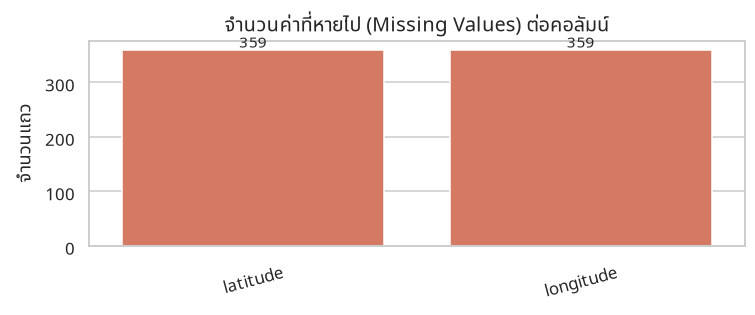

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_count'], ax=ax, color='#e76f51')
ax.set_title('จำนวนค่าที่หายไป (Missing Values) ต่อคอลัมน์', fontsize=13, fontweight='bold')
ax.set_ylabel('จำนวนแถว')
ax.set_xlabel('')
for i, v in enumerate(missing_summary['missing_count']):
    ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 1.6 Display Duplicate Records

In [10]:
dup_count = df.duplicated().sum()
dup_id_count = df['acc_code'].duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันทั้งหมด (all columns): {dup_count}")
print(f"จำนวน acc_code ที่ซ้ำกัน: {dup_id_count}")

จำนวนแถวที่ซ้ำกันทั้งหมด (all columns): 0
จำนวน acc_code ที่ซ้ำกัน: 0


### 1.7 Display Class Distribution\nสร้างตัวแปร `severity` (ระดับความรุนแรง) จาก `number_of_fatalities` และ `number_of_injuries` เพื่อใช้เป็น class สำหรับสำรวจและใช้ต่อใน Feature Engineering

In [11]:
def classify_severity(row):
    if row['number_of_fatalities'] > 0:
        return 'Fatal'
    elif row['number_of_injuries'] > 0:
        return 'Injury'
    else:
        return 'Property Damage Only'

df['severity'] = df.apply(classify_severity, axis=1)
class_dist = df['severity'].value_counts()
class_dist

severity
Injury                  36325
Property Damage Only    35275
Fatal                   10135
Name: count, dtype: int64

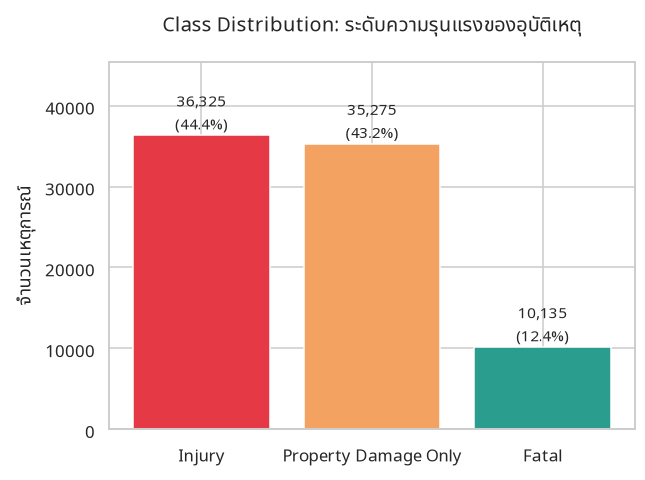

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ['#e63946', '#f4a261', '#2a9d8f']
bars = ax.bar(class_dist.index, class_dist.values, color=colors)
ax.set_title('Class Distribution: ระดับความรุนแรงของอุบัติเหตุ', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('จำนวนเหตุการณ์')
ax.set_ylim(0, class_dist.max() * 1.25)   # เผื่อพื้นที่ด้านบนไม่ให้ตัวเลขชนหัวเรื่อง
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + class_dist.max()*0.02, f'{h:,}\n({h/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## LAB2: Data Visualization

### 2.1 Histogram

findfont: Failed to find font weight bold, now using 400.


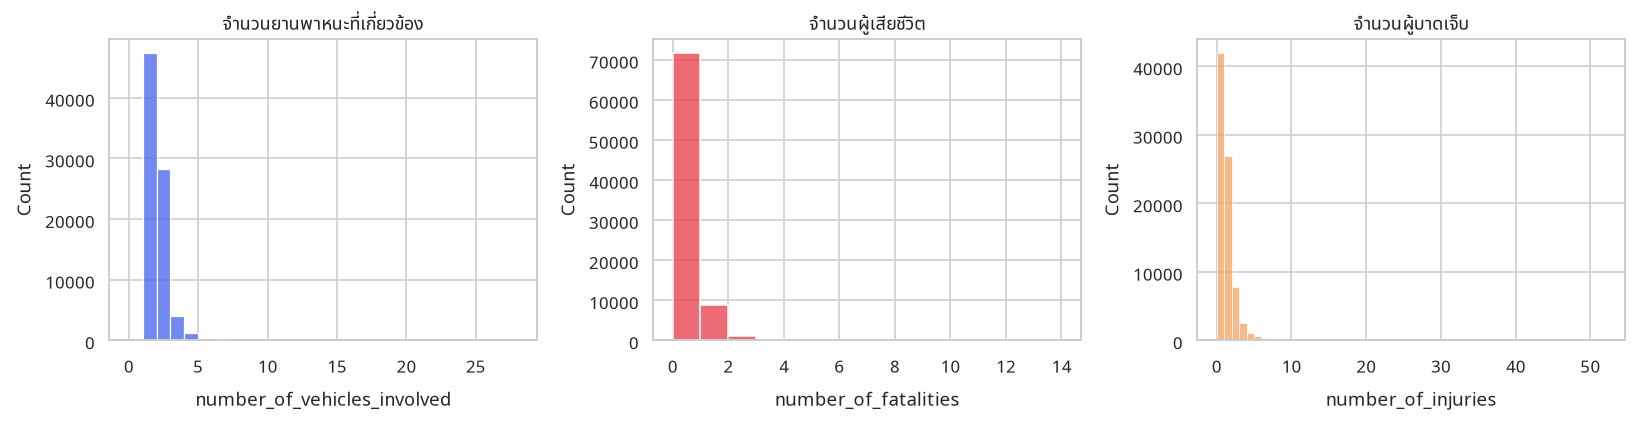

In [13]:
num_cols = ['number_of_vehicles_involved', 'number_of_fatalities', 'number_of_injuries']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['จำนวนยานพาหนะที่เกี่ยวข้อง', 'จำนวนผู้เสียชีวิต', 'จำนวนผู้บาดเจ็บ']
colors = ['#4361ee', '#e63946', '#f4a261']
for ax, col, title, c in zip(axes, num_cols, titles, colors):
    sns.histplot(df[col], bins=range(0, int(df[col].max())+2), ax=ax, color=c, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

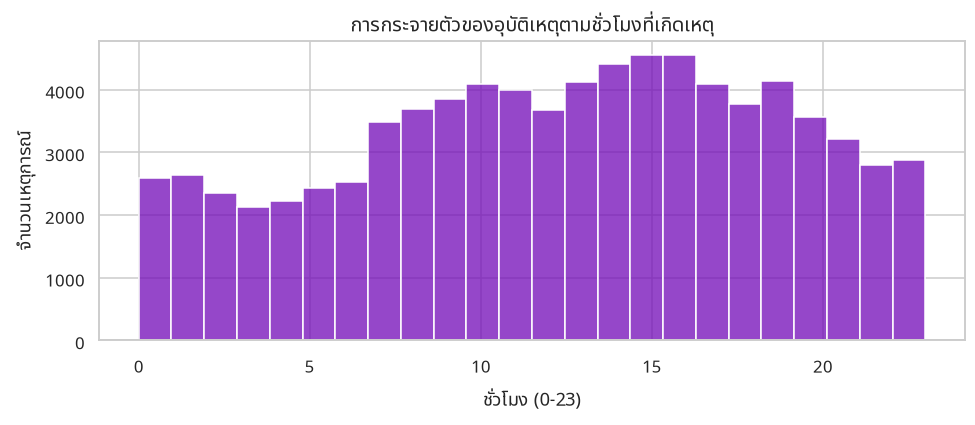

In [14]:
df['incident_datetime'] = pd.to_datetime(df['incident_datetime'])
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df['incident_datetime'].dt.hour, bins=24, ax=ax, color='#7209b7', edgecolor='white')
ax.set_title('การกระจายตัวของอุบัติเหตุตามชั่วโมงที่เกิดเหตุ', fontsize=13, fontweight='bold')
ax.set_xlabel('ชั่วโมง (0-23)')
ax.set_ylabel('จำนวนเหตุการณ์')
plt.tight_layout()
plt.show()

### 2.2 Correlation Heatmap

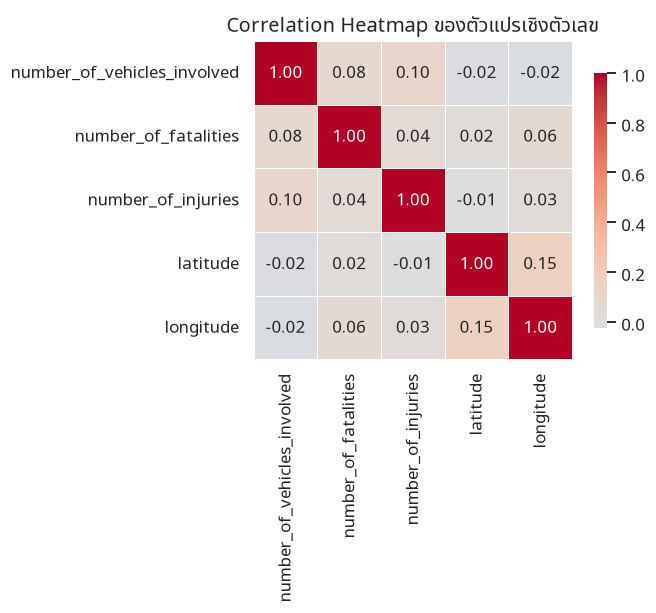

In [15]:
corr_cols = ['number_of_vehicles_involved', 'number_of_fatalities', 'number_of_injuries', 'latitude', 'longitude']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Correlation Heatmap ของตัวแปรเชิงตัวเลข', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 3: Data Cleaning

### 3.1 Missing Value Handling\nคอลัมน์ `latitude` และ `longitude` มีค่าหายไป — ใช้ median ของแต่ละจังหวัด (province) เติมค่า เพราะพิกัดควรใกล้เคียงกับอุบัติเหตุอื่นในจังหวัดเดียวกัน

In [16]:
print("ก่อนแก้ไข - missing lat/lon:", df['latitude'].isna().sum(), df['longitude'].isna().sum())

df['latitude'] = df.groupby('province_en')['latitude'].transform(lambda x: x.fillna(x.median()))
df['longitude'] = df.groupby('province_en')['longitude'].transform(lambda x: x.fillna(x.median()))

# เหลือกรณีจังหวัดที่ทั้งกลุ่มไม่มีพิกัดเลย ใช้ median รวมทั้งประเทศแทน
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())

print("หลังแก้ไข - missing lat/lon:", df['latitude'].isna().sum(), df['longitude'].isna().sum())

ก่อนแก้ไข - missing lat/lon: 359 359
หลังแก้ไข - missing lat/lon: 0 0


### 3.2 Duplicate Removal

In [17]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"จำนวนแถวก่อนลบซ้ำ: {before:,} | หลังลบซ้ำ: {after:,} | ลบไป: {before-after} แถว")

จำนวนแถวก่อนลบซ้ำ: 81,735 | หลังลบซ้ำ: 81,735 | ลบไป: 0 แถว


### 3.3 Incorrect Data Correction\nพิกัดของประเทศไทยอยู่ในช่วง latitude ~5.6–20.5 และ longitude ~97–105.6 — ค่านอกช่วงนี้ถือว่าผิดปกติ (data entry error) จะแก้ไขด้วยค่า median ของจังหวัดเดียวกันแทน

In [18]:
TH_LAT = (5.5, 21.0)
TH_LON = (97.0, 106.0)

bad_geo = (~df['latitude'].between(*TH_LAT)) | (~df['longitude'].between(*TH_LON))
print(f"จำนวนพิกัดผิดปกติที่พบ: {bad_geo.sum()}")
display(df.loc[bad_geo, ['province_en', 'latitude', 'longitude']])

df.loc[bad_geo, ['latitude', 'longitude']] = np.nan
df['latitude'] = df.groupby('province_en')['latitude'].transform(lambda x: x.fillna(x.median()))
df['longitude'] = df.groupby('province_en')['longitude'].transform(lambda x: x.fillna(x.median()))

bad_geo_after = (~df['latitude'].between(*TH_LAT)) | (~df['longitude'].between(*TH_LON))
print(f"จำนวนพิกัดผิดปกติหลังแก้ไข: {bad_geo_after.sum()}")

จำนวนพิกัดผิดปกติที่พบ: 3


,province_en,latitude,longitude
12264,unknown,41.549515,85.718742
18344,unknown,-0.001108,18.017161
40088,unknown,39.887517,67.583519


จำนวนพิกัดผิดปกติหลังแก้ไข: 0


### 3.4 Data Type Conversion

In [19]:
df['incident_datetime'] = pd.to_datetime(df['incident_datetime'])
df['report_datetime'] = pd.to_datetime(df['report_datetime'])
df['province_en'] = df['province_en'].astype('category')
df['vehicle_type'] = df['vehicle_type'].astype('category')

df.dtypes.to_frame(name='dtype').loc[['incident_datetime', 'report_datetime', 'province_en', 'vehicle_type']]

,dtype
incident_datetime,datetime64[us]
report_datetime,datetime64[us]
province_en,category
vehicle_type,category


### 3.5 เปรียบเทียบ Mean vs Median\nเปรียบเทียบผลของการเติมค่าด้วย Mean กับ Median ในคอลัมน์ `latitude` (ก่อนเติมค่าจริง) เพื่อแสดงว่า median ทนทานต่อ outlier มากกว่า

In [20]:
raw = pd.read_csv("thai_road_accident_2019_2022.csv")['latitude']
print(f"Mean (มีค่าผิดปกติปนอยู่):   {raw.mean():.4f}")
print(f"Median (มีค่าผิดปกติปนอยู่): {raw.median():.4f}")
print(f"Mean หลังตัดค่านอกช่วงไทย:   {raw[raw.between(*TH_LAT)].mean():.4f}")
print(f"Median หลังตัดค่านอกช่วงไทย: {raw[raw.between(*TH_LAT)].median():.4f}")
print("\n→ Mean เปลี่ยนแปลงมากกว่า Median อย่างเห็นได้ชัดเมื่อมี outlier แสดงว่า Median ทนทาน (robust) ต่อค่าผิดปกติมากกว่า")

Mean (มีค่าผิดปกติปนอยู่):   14.3775
Median (มีค่าผิดปกติปนอยู่): 14.4689
Mean หลังตัดค่านอกช่วงไทย:   14.3771
Median หลังตัดค่านอกช่วงไทย: 14.4689

→ Mean เปลี่ยนแปลงมากกว่า Median อย่างเห็นได้ชัดเมื่อมี outlier แสดงว่า Median ทนทาน (robust) ต่อค่าผิดปกติมากกว่า


## Part 4: Feature Engineering

### 4.1 Label Encoding\nใช้กับตัวแปรที่มีลำดับ (ordinal) เช่น `severity` (Property Damage Only < Injury < Fatal)

In [21]:
from sklearn.preprocessing import LabelEncoder

severity_order = {'Property Damage Only': 0, 'Injury': 1, 'Fatal': 2}
df['severity_encoded'] = df['severity'].map(severity_order)

df[['severity', 'severity_encoded']].drop_duplicates().sort_values('severity_encoded')

,severity,severity_encoded
4,Property Damage Only,0
0,Injury,1
2,Fatal,2


### 4.2 One-Hot Encoding\nใช้กับตัวแปรที่ไม่มีลำดับ (nominal) เช่น `weather_condition`

In [22]:
weather_ohe = pd.get_dummies(df['weather_condition'], prefix='weather')
df_encoded = pd.concat([df, weather_ohe], axis=1)

print("คอลัมน์ที่ได้จาก One-Hot Encoding:")
print(list(weather_ohe.columns))
df_encoded[['weather_condition'] + list(weather_ohe.columns)].head()

คอลัมน์ที่ได้จาก One-Hot Encoding:
['weather_clear', 'weather_dark', 'weather_foggy', 'weather_land slide', 'weather_natural disaster', 'weather_other', 'weather_rainy']


,weather_condition,weather_clear,weather_dark,weather_foggy,weather_land slide,weather_natural disaster,weather_other,weather_rainy
0,clear,True,False,False,False,False,False,False
1,clear,True,False,False,False,False,False,False
2,clear,True,False,False,False,False,False,False
3,clear,True,False,False,False,False,False,False
4,clear,True,False,False,False,False,False,False


## สรุป
- **LAB1**: สำรวจ dataset ขนาด ~81,700 แถว, 18 คอลัมน์ พบ missing values ในพิกัด (lat/lon) และไม่มี duplicate records
- **LAB2**: histogram แสดงว่าอุบัติเหตุส่วนใหญ่เกี่ยวข้องกับยานพาหนะ 1-2 คัน และ correlation heatmap แสดงความสัมพันธ์ระหว่างตัวแปรตัวเลข
- **Part 3**: เติมค่า missing และแก้ไขพิกัดผิดปกติด้วย median รายจังหวัด, แปลงชนิดข้อมูล datetime และ category
- **Part 4**: ใช้ Label Encoding กับตัวแปรที่มีลำดับ (severity) และ One-Hot Encoding กับตัวแปรไม่มีลำดับ (weather_condition)